### Environment Setup and MongoDB connection
Importing necessary libraries, initializing MongoDB connection and defining the database.

In [1]:
# Import necessary libraries

# Standard
import time
import gc

# Data Processing and Database
import pandas as pd
from pymongo import MongoClient
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, round, lit, when, to_timestamp, hour, unix_timestamp, lag
from functools import reduce
from pyspark.sql.window import Window
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# initialize MongoDB client and define the database(collection)
client = MongoClient("mongodb://localhost:27017/")
db = client['US-Accidents']
collection = db['accidents']

### Data Ingestion
By using chunking, we can read the CSV in segments and insert data to MongoDB without crashing system memory.

In [2]:
# Delete the existing collection to ensure no duplicates (use if you want to start fresh)
# collection.drop() # Uncomment this line to drop the collection before loading new data
# print(f"Collection dropped.") 

# Check if data already exists to avoid redundant uploads
mongo_count = collection.count_documents({})
print(f"Documents in MongoDB: {mongo_count}")

if mongo_count < 7700000:  # Assuming the dataset has > 7.7 million rows
    chunk_size = 10000  # Adjust based on system RAM
    total = 0
    # Read CSV in chunks and insert into MongoDB
    for chunk in pd.read_csv("US_Accidents_March23.csv", chunksize=chunk_size):
        records = chunk.to_dict("records")
        collection.insert_many(records)
        total += len(records)
        print(f"Loaded: {total} rows...")
    print(f"Done! Total {total} documents.")
else:
    print("Dataset already in MongoDB, skipping import.")

Documents in MongoDB: 7728394
Dataset already in MongoDB, skipping import.


### Schema Exploration

In [3]:
# Retrieve one document to inspect keys
doc = collection.find_one()
keys = list(doc.keys())

# Print keys in a structured grid for readability
chunk_size = 23
columns = [keys[i:i+chunk_size] for i in range(0, len(keys), chunk_size)]
max_len = max(len(col) for col in columns)

for row in range(max_len):
    line = ""
    for col_idx, c in enumerate(columns):
        if row < len(c):
            num = col_idx * chunk_size + row
            line += f"{num:<4}{c[row]:<30}"
    print(line)

0   _id                           23  Humidity(%)                   46  Astronomical_Twilight         
1   ID                            24  Pressure(in)                  
2   Source                        25  Visibility(mi)                
3   Severity                      26  Wind_Direction                
4   Start_Time                    27  Wind_Speed(mph)               
5   End_Time                      28  Precipitation(in)             
6   Start_Lat                     29  Weather_Condition             
7   Start_Lng                     30  Amenity                       
8   End_Lat                       31  Bump                          
9   End_Lng                       32  Crossing                      
10  Distance(mi)                  33  Give_Way                      
11  Description                   34  Junction                      
12  Street                        35  No_Exit                       
13  City                          36  Railway                       


### Performance Benchmarking
We are comparing an embedded document structure (all data in one record) against a referenced structure (data split across collections and joined via IDs).

In [4]:
# Embedded query test
start = time.time()
list(collection.find({"State": "CA"}).limit(1000))
embedded_time = time.time() - start
print(f"Embedded query execution: {embedded_time:.4f}s")

# Referenced query test
sample = list(collection.find().limit(10000))
accidents_ref = db["accidents_referenced"]
weather_ref = db["weather_referenced"]
accidents_ref.drop()
weather_ref.drop()

# Split data into two collections to simulate a relational structure
for doc in sample:
    weather_id = doc["_id"]
    weather_ref.insert_one({
        "weather_id": weather_id,
        "Weather_Condition": doc.get("Weather_Condition"),
        "Temperature(F)": doc.get("Temperature(F)")
    })
    accidents_ref.insert_one({
        "ID": doc.get("ID"),
        "Severity": doc.get("Severity"),
        "State": doc.get("State"),
        "weather_id": weather_id
    })

start = time.time()
accidents = list(accidents_ref.find({"State": "CA"}))
for acc in accidents:
    weather_ref.find_one({"weather_id": acc["weather_id"]})
referenced_time = time.time() - start

print(f"Referenced query execution: {referenced_time:.4f}s")
print(f"Embedded is {referenced_time/embedded_time:.1f}x faster.")

Embedded query execution: 0.0186s
Referenced query execution: 21.2879s
Embedded is 1147.6x faster.


### Cleanup
Dropping the temporary test collections

In [5]:
# Access the database
db = client['US-Accidents']

# Define the collections to be removed
temp_collections = ['accidents_referenced', 'weather_referenced']

for coll_name in temp_collections:
    if coll_name in db.list_collection_names():
        db[coll_name].drop()
        print(f"Successfully dropped temporary collection: {coll_name}")
    else:
        print(f"Collection {coll_name} does not exist or was already dropped.")

print("Cleanup complete.")

Successfully dropped temporary collection: accidents_referenced
Successfully dropped temporary collection: weather_referenced
Cleanup complete.


### Initializing Spark Session
We initialize Apache Spark with optimized configuration for local multi-core processing.
Note the memory allocation and adjust based on your hardware.

In [6]:
# Initialize Spark
# Adjust .config("spark.driver.memory", "5g") based on your system's RAM
spark = SparkSession.builder \
    .appName("US_Accidents_Regional_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "5g") \
    .getOrCreate()

print("Spark Session successfully initialized.")

Spark Session successfully initialized.


### Data Transfer
Fetching the necessary columns for the analysis, and converting the MongoDB cursor into a Spark Dataframe which we then cache in memory to speed up the queries.


In [7]:
# Defining the list of fields to retrieve from MongoDB, adjust as needed
cursor = collection.find(
    {},
    {
        "Severity": 1, 
        "State": 1, 
        "Start_Time": 1,
        "Weather_Condition": 1, 
        "Temperature(F)": 1, 
        "Visibility(mi)": 1,
        "Bump": 1,
        "Crossing": 1,
        "Junction": 1,
        "Railway": 1,
        "Traffic_Signal": 1,
        "Start_Lat": 1,
        "Start_Lng": 1,
        "City": 1,
        "ID": 1,
        "_id": 0
    }
)

# Convert the MongoDB cursor to a Pandas DataFrame
pandas_df = pd.DataFrame(list(cursor))
print("Rows fetched:", len(pandas_df))
print(pandas_df.head(3))
# Convert the Pandas DataFrame into a Spark DataFrame
df = spark.createDataFrame(pandas_df)
print("Data successfully converted to Spark DataFrame.")
# Display the schema
df.printSchema()
df.show(5)

Rows fetched: 7728394
    ID  Severity           Start_Time  Start_Lat  Start_Lng          City  \
0  A-1         3  2016-02-08 05:46:00  39.865147 -84.058723        Dayton   
1  A-2         2  2016-02-08 06:07:59  39.928059 -82.831184  Reynoldsburg   
2  A-3         2  2016-02-08 06:49:27  39.063148 -84.032608  Williamsburg   

  State  Temperature(F)  Visibility(mi) Weather_Condition   Bump  Crossing  \
0    OH            36.9            10.0        Light Rain  False     False   
1    OH            37.9            10.0        Light Rain  False     False   
2    OH            36.0            10.0          Overcast  False     False   

   Junction  Railway  Traffic_Signal  
0     False    False           False  
1     False    False           False  
2     False    False            True  
Data successfully converted to Spark DataFrame.
root
 |-- ID: string (nullable = true)
 |-- Severity: long (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- Start_Lat: double (nullable 

# Removing duplicates
This cell identifies and removes redundant records that occur at the same geographic coordinates within a 120-second window.

In [8]:
# Convert Start_Time column to standard Spark timestamp format for numerical operations
df = df.withColumn("Start_Time", to_timestamp("Start_Time"))

# Convert timestamps to Unix seconds to calculate the duration between events
df2 = df.withColumn("ts", unix_timestamp("Start_Time"))
# Define a window partitioned by geographic coordinates and ordered chronologically
w = Window.partitionBy("Start_Lat", "Start_Lng").orderBy("ts")

df_with_prev = (
    df2
    .withColumn("prev_ts", lag("ts").over(w))
    .withColumn("time_diff_sec", col("ts") - col("prev_ts"))
)

# Filter records occurring at the same location within a 0-120 second window
# These are flagged as "potential duplicates" for removal
possible_duplicates = df_with_prev.filter(
    (col("time_diff_sec") >= 0) & (col("time_diff_sec") <= 120)
)

print("Potential duplicates:")
possible_duplicates.select(
    "ID",
    "Start_Time",
    "prev_ts",
    "time_diff_sec",
    "Start_Lat",
    "Start_Lng",
    "City"

).show(10, truncate=False)


# Filtering out duplicates and showing cleaned data
df_clean = df.join(possible_duplicates.select("ID"), on="ID", how="left_anti")

print("Cleaned data with no duplicates:")
df_clean.show(10, truncate=False)
df = df_clean

# Cache the cleaned dataframe for further analysis
df.cache() 
df.count()

Potential duplicates:
+---------+-------------------+----------+-------------+-----------------+----------+------------+
|ID       |Start_Time         |prev_ts   |time_diff_sec|Start_Lat        |Start_Lng |City        |
+---------+-------------------+----------+-------------+-----------------+----------+------------+
|A-4738319|2022-04-16 00:50:00|1650059400|0            |24.928076        |-80.623798|Islamorada  |
|A-6870527|2020-12-11 17:11:00|1607699460|0            |25.010744        |-80.515575|Tavernier   |
|A-6556157|2021-02-19 14:13:00|1613736780|0            |25.03424200000001|-80.500431|Tavernier   |
|A-5197982|2022-07-16 16:25:00|1657977900|0            |25.197402        |-80.416375|Key Largo   |
|A-6908323|2020-12-22 13:22:30|1608636150|0            |25.439905        |-80.474961|Homestead   |
|A-6883295|2020-09-20 23:10:33|1600632633|0            |25.447736        |-80.485336|Homestead   |
|A-6858144|2020-11-23 03:39:30|1606095570|0            |25.447802        |-80.491357|Ho

7162203

##### Memory Optimization
Dropping RAM usage back to a manageable level after the data has been stored to Spark by deleting objects and calling the 'garbage collector'.

In [9]:
# Delete the heavy Python objects after Spark has cached the data
del pandas_df
if 'cursor' in locals(): del cursor

# Force Python to release the memory back to the OS
gc.collect()

print("Memory cleared. Python/Pandas copies removed.")

Memory cleared. Python/Pandas copies removed.


#### Grouping Weather Conditions
The dataset had a total of 144 different weather conditions, of which many need to be grouped into bigger categories so the data is not so fragmented.

In [10]:
# Create a new column "Weather_Group" based on the "Weather_Condition" column for better analysis
df = df.withColumn("Weather_Group",
    when(col("Weather_Condition").contains("Snow") |
         col("Weather_Condition").contains("Sleet") |
         col("Weather_Condition").contains("Ice") |
         col("Weather_Condition").contains("Wintry"), "Snow/Ice") # Grouped wintry conditions together
    .when(col("Weather_Condition").contains("Rain") |
          col("Weather_Condition").contains("Drizzle") |
          col("Weather_Condition").contains("Shower"), "Rain") # Grouped all rain-related conditions together
    .when(col("Weather_Condition").contains("Thunder") |
          col("Weather_Condition").contains("Storm") |
          col("Weather_Condition").contains("T-Storm") |
          col("Weather_Condition").contains("Tornado"), "Storm") # Grouped all storm-related conditions together
    .when(col("Weather_Condition").contains("Fog") |
          col("Weather_Condition").contains("Haze") |
          col("Weather_Condition").contains("Mist") |
          col("Weather_Condition").contains("Smoke") |
          col("Weather_Condition").contains("Dust") |
          col("Weather_Condition").contains("Sand") |
          col("Weather_Condition").contains("Volcanic Ash"), "Low Visibility") # Grouped all low visibility conditions together
    .when(col("Weather_Condition").contains("Cloud") |
          col("Weather_Condition").contains("Overcast"), "Cloudy") # Grouped all cloudy conditions together
    .when(col("Weather_Condition").contains("Clear") |
          col("Weather_Condition").contains("Fair"), "Fair/Clear") # Grouped all clear conditions together
    .when(col("Weather_Condition").contains("Wind") |
          col("Weather_Condition").contains("Breezy") |
          col("Weather_Condition").contains("Squall"), "Windy") # Windy conditions grouped together
    .when(col("Weather_Condition").contains("Hail"), "Hail")
    .when(col("Weather_Condition").isNull() | (col("Weather_Condition") == "nan") |
          (col("Weather_Condition") == "N/A Precipitation"), "Unknown")
    .otherwise("Other")
)

# Calculate the number of accidents and average severity to display a brief analysis
df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .show()

+--------------+---------+------------+
| Weather_Group|accidents|avg_severity|
+--------------+---------+------------+
|    Fair/Clear|  3134913|        2.19|
|        Cloudy|  2957669|        2.24|
|          Rain|   504198|        2.26|
|Low Visibility|   187480|        2.18|
|       Unknown|   161460|        2.26|
|      Snow/Ice|   156962|        2.24|
|         Storm|    59340|         2.2|
|          Hail|      106|        2.24|
|         Windy|       75|        2.29|
+--------------+---------+------------+



### Check if there is still category to add on Weather_Groups

In [11]:
# Checking if there are any weather conditions that are not categorized
df.filter(col("Weather_Group") == "Other") \
    .groupBy("Weather_Condition") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()


+-----------------+-----+
|Weather_Condition|count|
+-----------------+-----+
+-----------------+-----+



##### Saving weather groups to MongoDB

In [12]:
# Save the Weather_Group summary results to MongoDB
weather_group_results = df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .toPandas().to_dict("records")

# Drop the existing collection and insert the new results
db["weather_group_results"].drop()
db["weather_group_results"].insert_many(weather_group_results)
print(f"{len(weather_group_results)} Weather_Group results saved to MongoDB")

9 Weather_Group results saved to MongoDB


# Heikki's Analysis

# Regional Differences
For conducting regional analysis, the states will be grouped to Northwest-Northeast-Southeast-Southwest.
![Image of States Grouped to NW-NE-SE-SW](https://i.vgy.me/dD8ZwC.png)


In [13]:
# Categorizing the  states into four geographic sectors for analysis

# Define the region lists
northeast = ['CT', 'DC', 'DE', 'IL', 'IN', 'IA', 'KY', 'ME', 'MD', 'MA', 'MI', 'MN', 'NH', 'NJ', 'NY', 'OH', 'PA', 'RI', 'VT', 'VA', 'WV', 'WI']
northwest = ['AK', 'ID', 'MT', 'NE', 'ND', 'OR', 'SD', 'WA', 'WY']
southeast = ['AL', 'AR', 'FL', 'GA', 'LA', 'MS', 'MO', 'NC', 'SC', 'TN']
southwest = ['AZ', 'CA', 'CO', 'HI', 'KS', 'NM', 'NV', 'OK', 'TX', 'UT']

# Apply the grouping logic to create a 'Region' column
df = df.withColumn("Region",
    when(col("State").isin(northeast), "Northeast")
    .when(col("State").isin(northwest), "Northwest")
    .when(col("State").isin(southeast), "Southeast")
    .when(col("State").isin(southwest), "Southwest")
    .otherwise("Other")
)

# Verify counts per region
df.groupBy("Region").count().orderBy("count", ascending=False).show()

+---------+-------+
|   Region|  count|
+---------+-------+
|Southwest|2651637|
|Southeast|2120816|
|Northeast|2052619|
|Northwest| 337131|
+---------+-------+



### Regional Severity Differences
Calculating the percentage of accidents classified as severe (3-4) vs minor accidents (1-2) within each demographic group. 


In [40]:
# Ensure the DataFrame is registered as a view
df.createOrReplaceTempView("accidents_view")

# SQL Query to calculate total accidents, severe counts, and percentages per region
regional_severity_sql = """
SELECT 
    Region,
    COUNT(*) AS Total_Accidents,
    SUM(CASE WHEN Severity >= 3 THEN 1 ELSE 0 END) AS Severe_Count,
    ROUND((SUM(CASE WHEN Severity >= 3 THEN 1 ELSE 0 END) / COUNT(*)) * 100, 2) AS Severe_Percentage
FROM accidents_view
GROUP BY Region
ORDER BY Severe_Percentage DESC
"""

# Show results
sql_results = spark.sql(regional_severity_sql)
sql_results.show()

+---------+---------------+------------+-----------------+
|   Region|Total_Accidents|Severe_Count|Severe_Percentage|
+---------+---------------+------------+-----------------+
|Northeast|        2052619|      530395|            25.84|
|Southwest|        2651637|      501166|             18.9|
|Southeast|        2120816|      376780|            17.77|
|Northwest|         337131|       54365|            16.13|
+---------+---------------+------------+-----------------+



+---------+-------+------+------------------+
|   Region|  Minor|Severe| Severe_Percentage|
+---------+-------+------+------------------+
|Northeast|1522224|530395| 25.83991476255457|
|Southwest|2150471|501166| 18.90024916683543|
|Southeast|1744036|376780|17.765803351162948|
|Northwest| 282766| 54365|16.125778999854656|
+---------+-------+------+------------------+



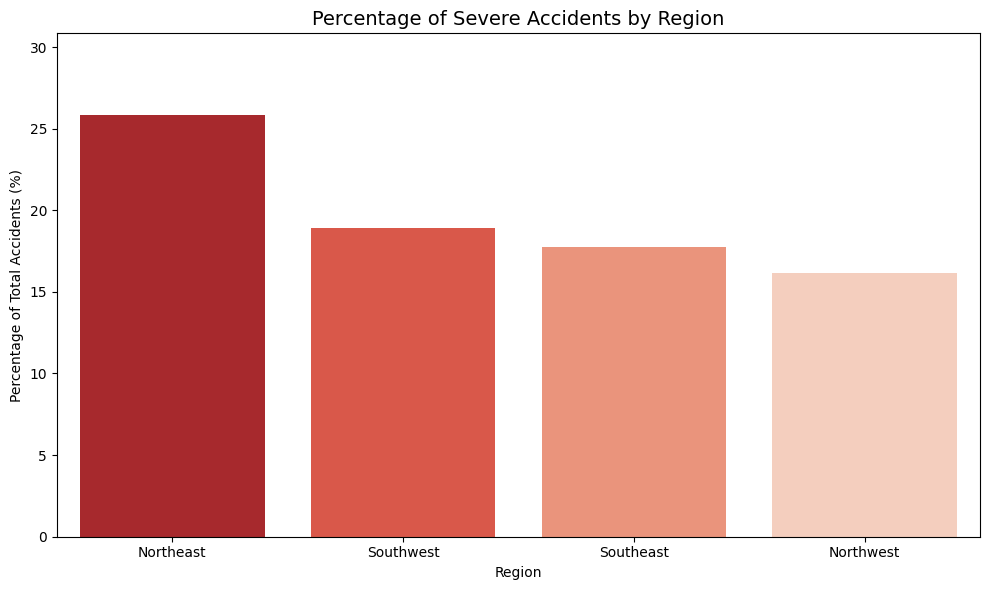

In [14]:
# Calculating the % of Severe (3-4) vs Minor (1-2) accidents per region

# Define severity categories
df_prop = df.withColumn("Severity_Type", 
    when(col("Severity") >= 3, "Severe")
    .otherwise("Minor")
)
# Pivot the data to get percentages for a table
regional_pivot = df_prop.groupBy("Region").pivot("Severity_Type").count()
regional_pivot = regional_pivot.withColumn(
    "Severe_Percentage", 
    (col("Severe") / (col("Severe") + col("Minor"))) * 100
).orderBy("Severe_Percentage", ascending=False)

regional_pivot.show()
# Pivot and calculate percentages
severity_pivot = df_prop.groupBy("Region").pivot("Severity_Type").count()
severity_pivot = severity_pivot.withColumn(
    "Severe_Percentage", 
    round((col("Severe") / (col("Severe") + col("Minor"))) * 100, 2)
).orderBy("Severe_Percentage", ascending=False)

# Convert to Pandas for visualization
severity_pd = severity_pivot.toPandas()

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x="Region", y="Severe_Percentage", data=severity_pd, hue="Region", palette="Reds_r", legend=False)
plt.title("Percentage of Severe Accidents by Region", fontsize=14)
plt.ylabel("Percentage of Total Accidents (%)")
plt.xlabel("Region")
plt.ylim(0, max(severity_pd["Severe_Percentage"]) + 5)
plt.tight_layout()

plt.show()

##### Conclusions:
- The Northeast leads the nation in danger density with 25.8% of its accidents classified as severe. This is the only region where more than a quarter of all accidents reach level 3 or 4 severity.
- Northwest has the lowest percentage of severe accidents, followed closely by the Southeast and Southwest.
- Nearly 10% gap between the highest and lowest regions suggest that regional factors play a major role.

--- Average Severity Score by Region ---
      Region  Avg_Severity
0  Northeast         2.293
1  Southwest         2.193
2  Southeast         2.187
3  Northwest         2.186
----------------------------------------


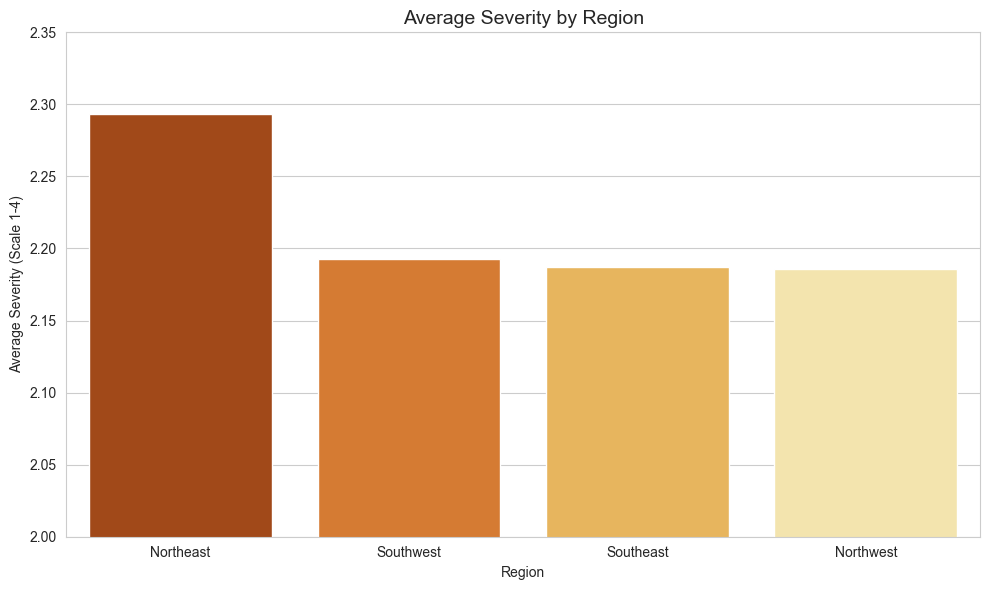

In [15]:
# Calculate the average severity per region with Spark's 'avg' function to find the arithmetic mean
avg_severity_region = df.groupBy("Region") \
    .agg(round(avg("Severity"), 3).alias("Avg_Severity")) \
    .orderBy("Avg_Severity", ascending=False)

# Convert to Pandas for plotting
avg_severity_pd = avg_severity_region.toPandas()

# Print the numeric values for the report
print("--- Average Severity Score by Region ---")
print(avg_severity_pd)
print("-" * 40)

# Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plotting the Average Severity
ax = sns.barplot(x="Region", y="Avg_Severity", data=avg_severity_pd, hue="Region", palette="YlOrBr_r", legend=False)

plt.title("Average Severity by Region", fontsize=14)
plt.ylabel("Average Severity (Scale 1-4)")
plt.xlabel("Region")

# Adjusting y-axis
plt.ylim(2.0, 2.35) 

plt.tight_layout()
plt.show()

##### Conclusions
- Northeast has also the highest average severity score at 2.293, which confirms that accidents there are the most severe on average compared to other regions.
- The rest of the regions are statistically nearly identical.

### Weather Condition's effect on severity.
Analyzing it by plotting a heatmap with weather conditions and their severity within each region.

In [16]:
# Calculating the percentage of 'Unknown' weather reports per region to assess data reliability.

weather_quality = df.groupBy("Region", "Weather_Group") \
    .count()

# Pivot to see Unknown vs Known easily
quality_pivot = weather_quality.groupBy("Region").pivot("Weather_Group").sum("count").fillna(0)

# Identify all columns that are NOT the 'Region' column
cols_to_sum = [col(c) for c in quality_pivot.columns if c != 'Region']

# Calculate % Unknown
# Formula: (Unknown / Total) * 100
quality_pivot = quality_pivot.withColumn("Total", reduce(lambda x, y: x + y, cols_to_sum)) \
                             .withColumn("Percent_Unknown", round((col("Unknown") / col("Total")) * 100, 2)) \
                             .select("Region", "Total", "Unknown", "Percent_Unknown") \
                             .orderBy("Percent_Unknown", ascending=False)

quality_pivot.show()

+---------+-------+-------+---------------+
|   Region|  Total|Unknown|Percent_Unknown|
+---------+-------+-------+---------------+
|Northeast|2052619|  64286|           3.13|
|Southwest|2651637|  64372|           2.43|
|Northwest| 337131|   6334|           1.88|
|Southeast|2120816|  26468|           1.25|
+---------+-------+-------+---------------+



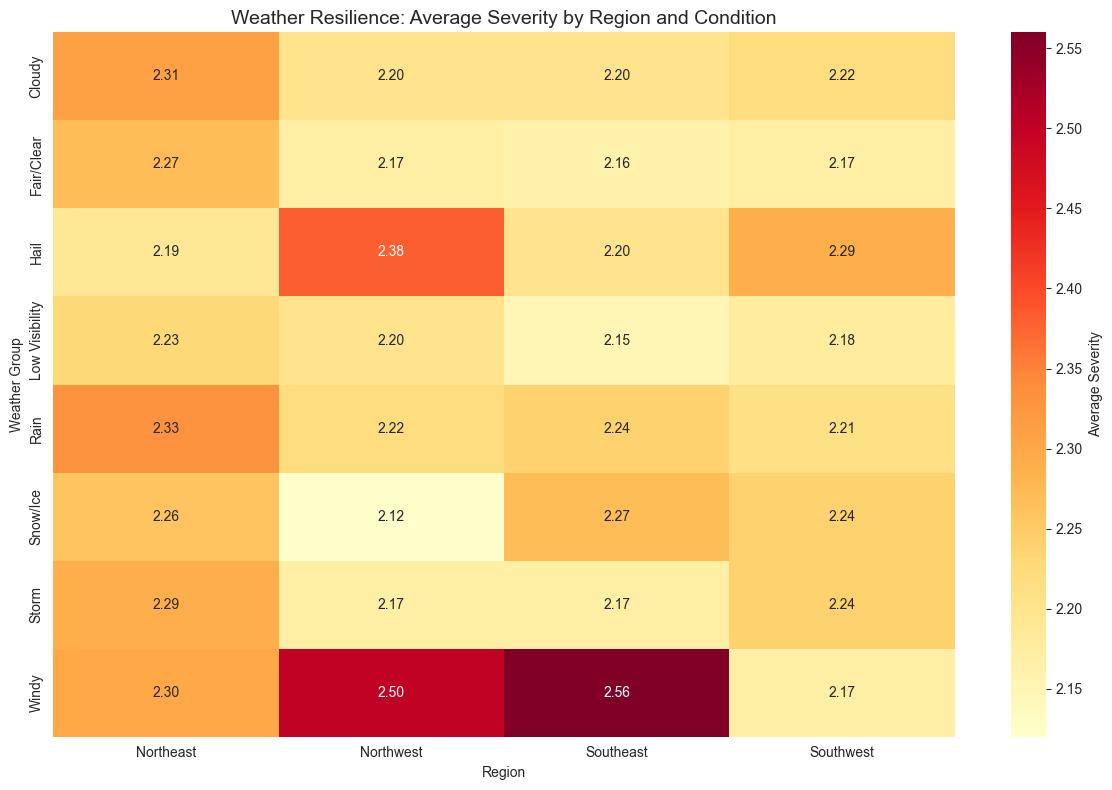

In [17]:
# Aggregate average severity by Region and Weather Group
weather_resilience = df.groupBy("Region", "Weather_Group") \
    .agg(round(avg("Severity"), 2).alias("Avg_Severity")) \
    .filter(col("Weather_Group") != "Unknown")

# Pivot for Heatmap
weather_resilience_pd = weather_resilience.toPandas()
weather_pivot = weather_resilience_pd.pivot(index="Weather_Group", columns="Region", values="Avg_Severity")

# Visualization: Heatmap
plt.figure(figsize=(12, 8))
# Note: Using cbar_kws to correctly set the colorbar label
sns.heatmap(weather_pivot, 
            annot=True, 
            cmap="YlOrRd", 
            fmt=".2f", 
            cbar_kws={'label': 'Average Severity'})

plt.title("Weather Resilience: Average Severity by Region and Condition", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Weather Group")
plt.tight_layout()
plt.show()

Conclusions:
- Northeast shows relatively high severity across all categories and is particularly sensitive to rainy conditions.
- The most severe accidents in the entire dataset occur during windy conditions in the Southeast (2.56) and Northwest (2.50). These regions seem to have the lowest resilience to wind related events.
- Southwest has the lowest severity scores across the board, suggesting that the region’s geography or road design is better suited for maintaining safety during diverse weather conditions.
- The data suggests that severity is not just about the weather itself, but how well a region's infrastructure and drivers adapt to it (e.g., the Southeast shows lower severity for snow than for wind).

### Regional Infrastructure Analysis

Analyzing five points of interest, which are: Bump, Crossing, Junction, Railway, and Traffic_Signal.

Beginning by calculating the involvement rate to determine what percentage of a region's total accidents actually occur at those locations by: $$ InvolvementRate = (\frac{FeatureCount}{Regiontotal})*100 %)$$

In [18]:

# Define the infrastructure columns
infra_cols = ["Bump", "Crossing", "Junction", "Railway", "Traffic_Signal"]

# Reference the regional totals calculated earlier
region_totals = df.groupBy("Region").count().withColumnRenamed("count", "Region_Total")

# Run the main spark analysis
infra_stats_list = []

# Iterate through features to collect subset statistics
for feature in infra_cols:
    # Filter for records where the feature is True and calculate counts and average severity by region
    feature_stats = df.filter(col(feature) == True) \
        .groupBy("Region") \
        .agg(
            count("*").alias("Feature_Count"),
            round(avg("Severity"), 3).alias("Avg_Severity")
        ) \
        .withColumn("Infrastructure_Type", lit(feature))
    
    infra_stats_list.append(feature_stats)

# Combine results and calculate percentages
infra_master_df = reduce(lambda df1, df2: df1.union(df2), infra_stats_list)

# Join with regional totals to calculate the normalized involvement percentage
infra_master_df = reduce(lambda df1, df2: df1.union(df2), infra_stats_list)
infra_final_df = infra_master_df.join(region_totals, "Region")
infra_final_df = infra_final_df.withColumn(
    "Involvement_Rate_Percent", 
    round((col("Feature_Count") / col("Region_Total")) * 100, 2)
)

# Convert to pandas (One master table for all visuals)
infra_master_pd = infra_final_df.toPandas()

# Visualize the table
print("--- Infrastructure Regional Analysis Summary ---")
print(infra_master_pd[['Region', 'Infrastructure_Type', 'Involvement_Rate_Percent', 'Avg_Severity']].sort_values(['Infrastructure_Type', 'Region']))


--- Infrastructure Regional Analysis Summary ---
       Region Infrastructure_Type  Involvement_Rate_Percent  Avg_Severity
19  Northeast                Bump                      0.02         2.222
4   Northwest                Bump                      0.10         2.154
9   Southeast                Bump                      0.02         2.004
14  Southwest                Bump                      0.08         2.096
18  Northeast            Crossing                      9.48         2.159
3   Northwest            Crossing                     13.44         2.073
8   Southeast            Crossing                     14.31         2.021
13  Southwest            Crossing                     10.03         2.045
17  Northeast            Junction                      8.75         2.354
2   Northwest            Junction                      4.89         2.246
7   Southeast            Junction                      5.10         2.352
12  Southwest            Junction                      8.68    

##### Visualization
Heatmap of Infrastructure Involvement, and bar chart for impact of accidents near the same points of interests.

--- Infrastructure Regional Analysis Summary ---


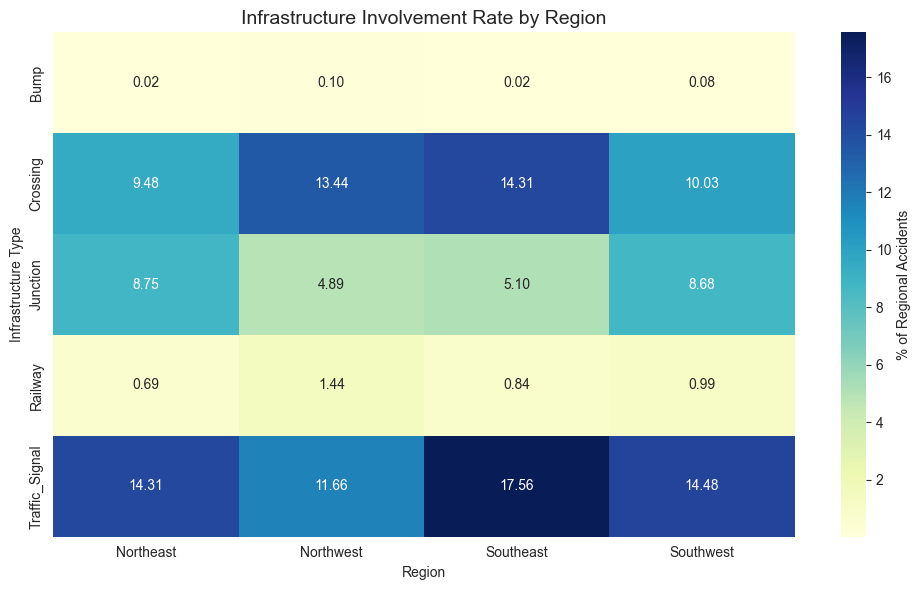

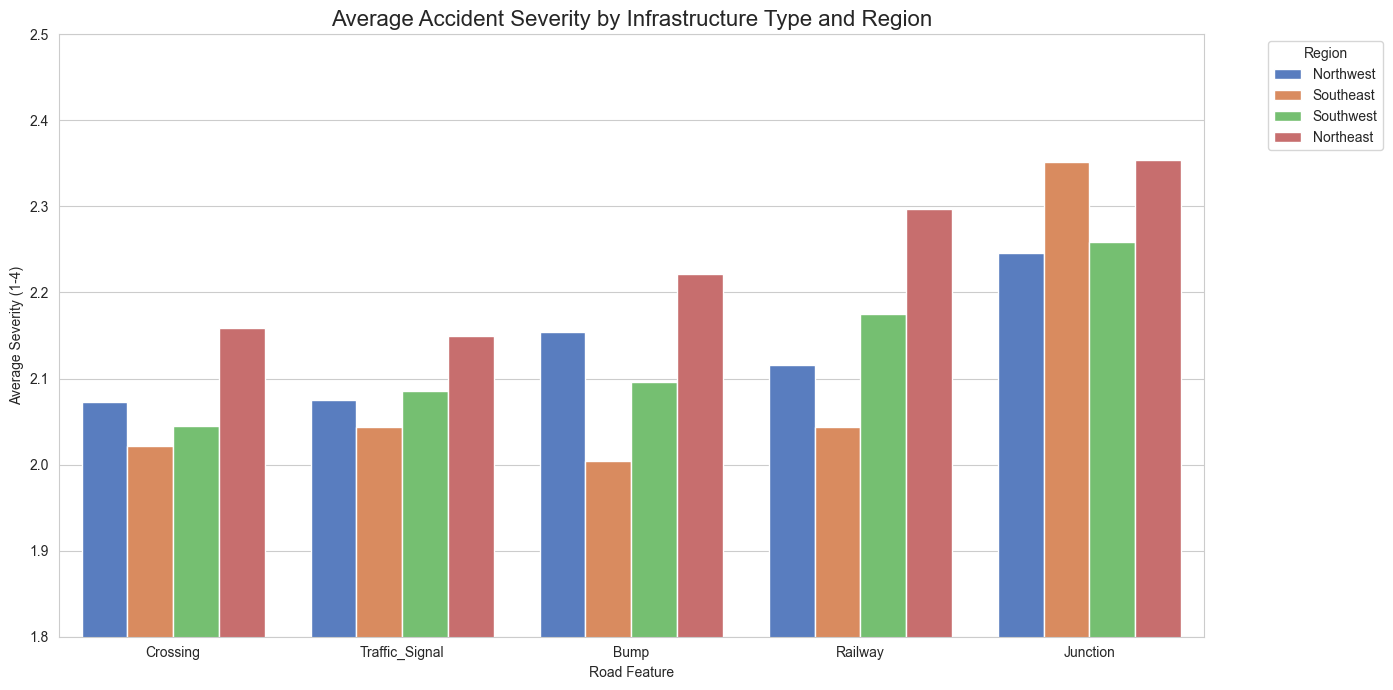

In [41]:
print("--- Infrastructure Regional Analysis Summary ---")

# Heatmap of Involvement (%)
# We just pivot the data we already have in RAM
pivot_dist = infra_master_pd.pivot(index="Infrastructure_Type", columns="Region", values="Involvement_Rate_Percent")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_dist, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': '% of Regional Accidents'})
plt.title("Infrastructure Involvement Rate by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Infrastructure Type")
plt.tight_layout()
plt.show()

# Creating an order for the bar chart based on average severity to make it more intuitive
ordered_infra = (
    infra_master_pd.groupby("Infrastructure_Type")["Avg_Severity"]
    .mean()
    .sort_values(ascending=True)
    .index
)

# Severity Bar Chart
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x="Infrastructure_Type", y="Avg_Severity", hue="Region", data=infra_master_pd, palette="muted", order=ordered_infra)
plt.title("Average Accident Severity by Infrastructure Type and Region", fontsize=16)
plt.ylabel("Average Severity (1-4)")
plt.xlabel("Road Feature")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(1.8, 2.5) 
plt.tight_layout()
plt.show()

##### Conclusions:
- While Traffic Signals see the highest volume of accidents, junctions result in significantly higher impact accidents across all regions.
- Southeastern region has the highest involvement of traffic signals in accidents, whereas the Northeast leads the nation in average accident severity across all road features.
- Bumps and Railways contribute to less than 1.5% of regional accidents, showing that their effect is marginal compared to intersections and signals

#### Saving the Summaries to MongoDB 

In [22]:
# Saving the three regional summary tables to MongoDB
final_summary_tables = {
    "results_weather_summary": weather_resilience_pd,
    "results_regional_severity": severity_pd,
    "results_infrastructure_summary": infra_master_pd
}

print("--- Starting the save process to MongoDB ---")

for table_name, data_table in final_summary_tables.items():
    try:
        # Delete the old version in the database so we have a fresh start
        db[table_name].drop()
        
        # Turn the table into a list of rows and save them
        rows_to_save = data_table.to_dict("records")
        
        if rows_to_save:
            db[table_name].insert_many(rows_to_save)
            print(f"OK: Saved {table_name} ({len(rows_to_save)} rows)")
        else:
            print(f"Empty: {table_name} had no data to save.")
            
    except Exception as error:
        print(f"Error saving {table_name}: {error}")

print("-" * 50)
print("Summaries have been saved to MongoDB.")

--- Starting the save process to MongoDB ---
OK: Saved results_weather_summary (32 rows)
OK: Saved results_regional_severity (4 rows)
OK: Saved results_infrastructure_summary (20 rows)
--------------------------------------------------
Summaries have been saved to MongoDB.


# JARMO'S ANALYSIS

### Count of accident by severity avg %&/#¤%&/¤%#&#¤%&#¤&"#¤!%#&/¤&"#¤%

In [23]:
df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .show()


+--------------+---------+------------+
| Weather_Group|accidents|avg_severity|
+--------------+---------+------------+
|    Fair/Clear|  3134913|        2.19|
|        Cloudy|  2957669|        2.24|
|          Rain|   504198|        2.26|
|Low Visibility|   187480|        2.18|
|       Unknown|   161460|        2.26|
|      Snow/Ice|   156962|        2.24|
|         Storm|    59340|         2.2|
|          Hail|      106|        2.24|
|         Windy|       75|        2.29|
+--------------+---------+------------+



### Check severity count

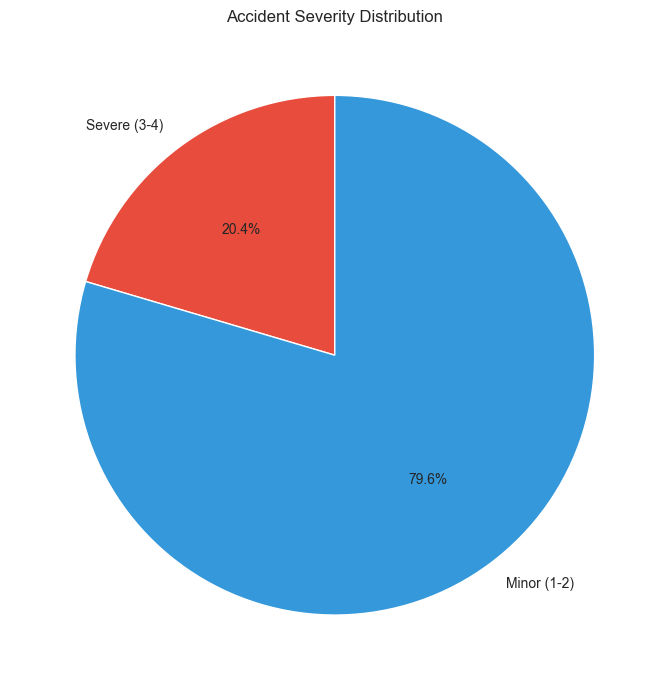

In [24]:
severe = df.filter(df["Severity"] >= 3).count()
minor = df.filter(df["Severity"] < 3).count()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [severe, minor],
    labels=["Severe (3-4)", "Minor (1-2)"],
    autopct="%1.1f%%",
    colors=["#e74c3c", "#3498db"],
    startangle=90
)
ax.set_title("Accident Severity Distribution")
plt.tight_layout()
plt.show()

### Visibility during accidents 

In [25]:
df.createOrReplaceTempView("weather_accidents")
spark.sql("""
    SELECT 
        CASE 
            WHEN `Visibility(mi)` < 1 THEN 'Under 1 mile'
            WHEN `Visibility(mi)` < 5 THEN '1-5 miles'
            ELSE 'Over 5 miles'
        END as visibility,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    GROUP BY visibility
    ORDER BY avg_severity DESC
""").show()

+------------+---------+------------+
|  visibility|accidents|avg_severity|
+------------+---------+------------+
|   1-5 miles|   470062|        2.24|
|Over 5 miles|  6585078|        2.22|
|Under 1 mile|   107063|        2.21|
+------------+---------+------------+



### Temperature during accidents 

In [26]:
spark.sql("""
    SELECT 
        CASE 
            WHEN `Temperature(F)` < 32 THEN 'Freezing (below 32F)'
            WHEN `Temperature(F)` < 60 THEN 'Cool (32-60F)'
            ELSE 'Warm (above 60F)'
        END as temperature,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    GROUP BY temperature
    ORDER BY accidents DESC
""").show()

+--------------------+---------+------------+
|         temperature|accidents|avg_severity|
+--------------------+---------+------------+
|    Warm (above 60F)|  4226783|        2.22|
|       Cool (32-60F)|  2437880|        2.22|
|Freezing (below 32F)|   497540|        2.25|
+--------------------+---------+------------+



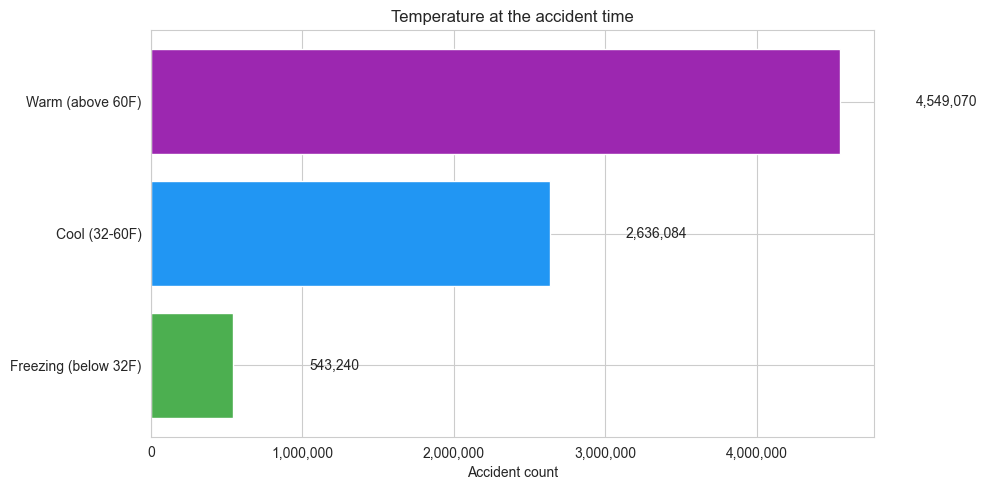

In [27]:
data = {
    "temperature": ["Warm (above 60F)", "Cool (32-60F)", "Freezing (below 32F)"],
    "accidents": [4549070, 2636084, 543240]
}

temp_df = pd.DataFrame(data)
temp_df = temp_df.sort_values("accidents")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(temp_df["temperature"], temp_df["accidents"], color=["#4CAF50", "#2196F3", "#9C27B0"])

for bar in bars:
    width = bar.get_width()
    ax.text(width + 500000, bar.get_y() + bar.get_height() / 2,
            f"{width:,}", va="center", fontsize=10)

ax.set_xlabel("Accident count")
ax.set_title("Temperature at the accident time")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

### Cross analysis between temperature and weather group 

In [29]:
cross_analysis_pd = spark.sql("""
    SELECT
        Weather_Group,
        CASE
            WHEN `Temperature(F)` < 32 THEN 'Freezing'
            WHEN `Temperature(F)` < 60 THEN 'Cool'
            ELSE 'Warm'
        END as temperature,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    WHERE Weather_Group IN ('Cloudy', 'Low Visibility', 'Unknown', 'Snow/Ice', 'Storm', 'Hail', 'Windy', 'Rain', 'Fair/Clear')
    GROUP BY Weather_Group, temperature
    ORDER BY accidents DESC
""").toPandas()

print(cross_analysis_pd)

     Weather_Group temperature  accidents  avg_severity
0       Fair/Clear        Warm    1965140          2.19
1           Cloudy        Warm    1764470          2.24
2           Cloudy        Cool    1015398          2.24
3       Fair/Clear        Cool     992613          2.19
4             Rain        Cool     285751          2.25
5             Rain        Warm     214272          2.27
6           Cloudy    Freezing     177801          2.27
7       Fair/Clear    Freezing     177160          2.23
8          Unknown        Warm     142056          2.25
9         Snow/Ice    Freezing     118781          2.25
10  Low Visibility        Cool      88264          2.16
11  Low Visibility        Warm      84961          2.21
12           Storm        Warm      55433          2.20
13        Snow/Ice        Cool      37788          2.23
14  Low Visibility    Freezing      14255          2.18
15         Unknown        Cool      14122          2.34
16         Unknown    Freezing       5282       

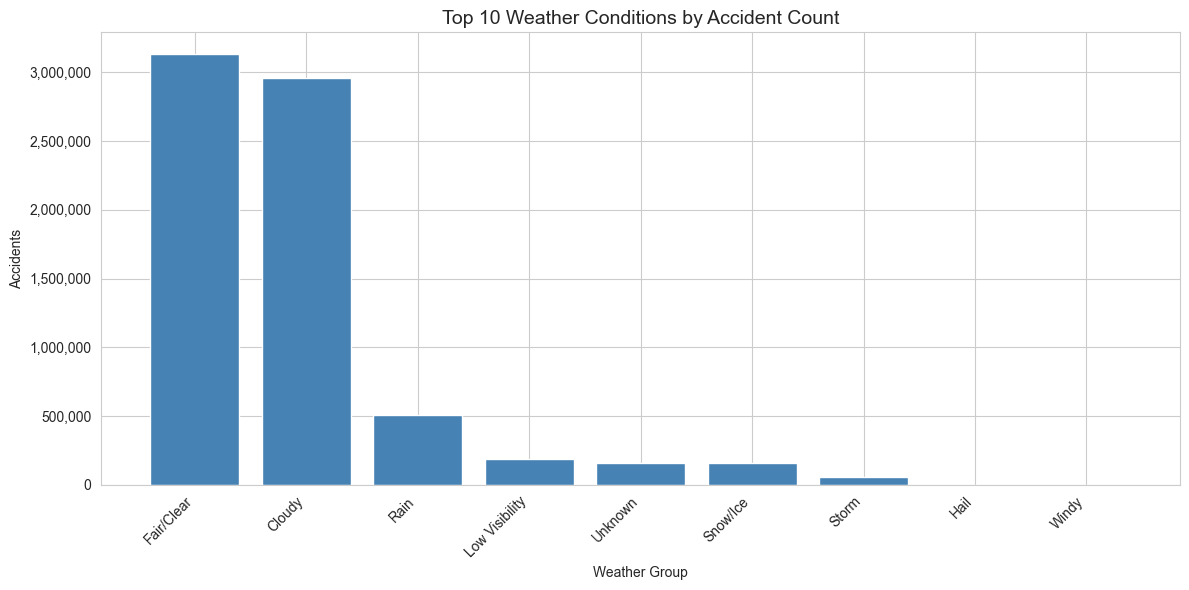

In [30]:
weather_pd = df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .limit(10) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(weather_pd["Weather_Group"], 
              weather_pd["accidents"],
              color="steelblue")
ax.set_title("Top 10 Weather Conditions by Accident Count", fontsize=14)
ax.set_xlabel("Weather Group")
ax.set_ylabel("Accidents")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

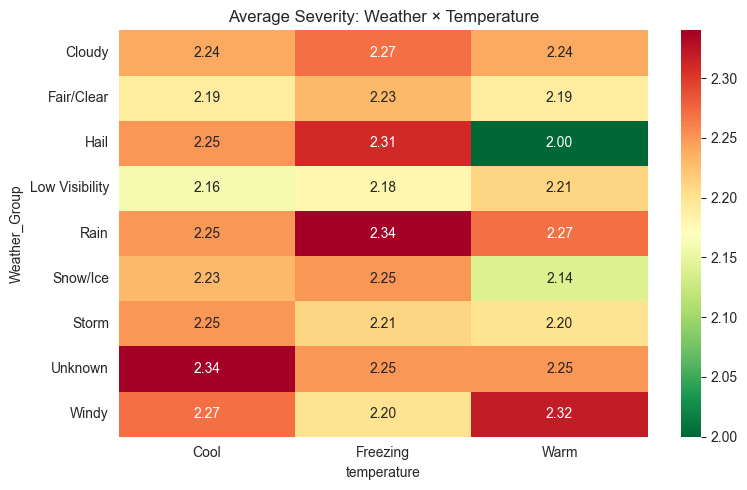

In [31]:
pivot = cross_analysis_pd.pivot(index="Weather_Group",
                                columns="temperature",
                                values="avg_severity")


fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax)
ax.set_title("Average Severity: Weather × Temperature")
plt.tight_layout()
plt.show()

# EMMI'S ANALYSIS

+----+------+
|hour| count|
+----+------+
|   0| 98319|
|   1| 84200|
|   2| 81419|
|   3| 73411|
|   4|148798|
|   5|212751|
|   6|385077|
|   7|561466|
|   8|552926|
|   9|344415|
|  10|323883|
|  11|333240|
|  12|325382|
|  13|360543|
|  14|408952|
|  15|481435|
|  16|536182|
|  17|532643|
|  18|400914|
|  19|273672|
|  20|207036|
|  21|173330|
|  22|150812|
|  23|111397|
+----+------+



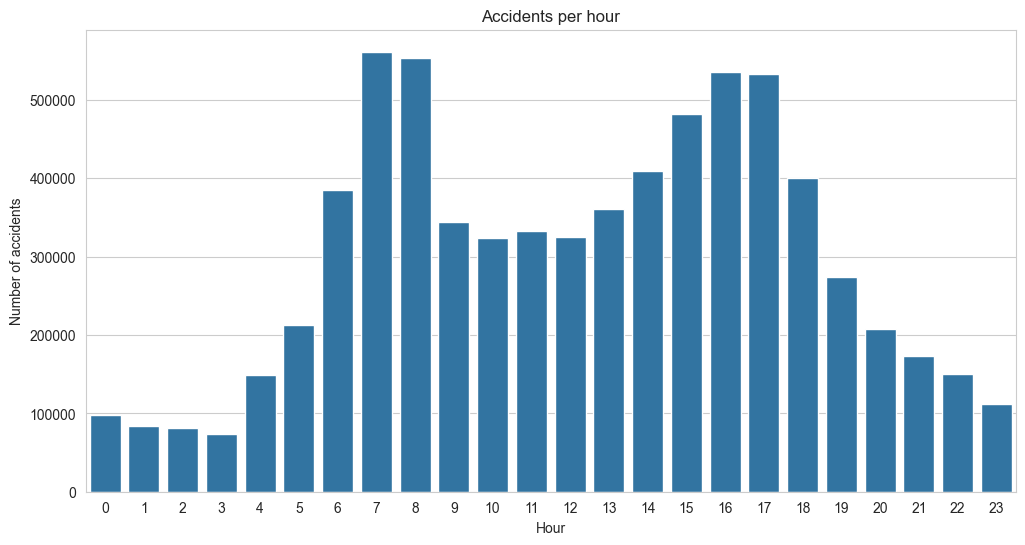

In [32]:
from pyspark.sql.functions import to_timestamp, hour

## df = spark.read.csv("US_Accidents_March23.csv", header=True, inferSchema=True) <--- EI LADATA DATASETTIÄ UUDELLEEN, jotta Tiinan tekemä puhdistus toimii
## df = df.withColumn("Start_Time", to_timestamp("Start_Time")) <--- EI LADATA DATASETTIÄ UUDELLEEN, jotta Tiinan tekemä puhdistus toimii

df = df.withColumn("hour", hour("Start_Time"))
acc_per_hour = df.groupBy("hour").count().orderBy("hour")
acc_per_hour.show(24)
pdf = acc_per_hour.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=pdf, x="hour", y="count")
plt.title("Accidents per hour")
plt.xlabel("Hour")
plt.ylabel("Number of accidents")
plt.show()


In [33]:
#Top 5 the most dangerous hours when accidents occurs
from pyspark.sql.functions import col
 
top5_hours = acc_per_hour.orderBy(col("count").desc()).limit(5)
 
print("Top 5 hours - the most dangerous hours:")
top5_hours.show()
 

Top 5 hours - the most dangerous hours:
+----+------+
|hour| count|
+----+------+
|   7|561466|
|   8|552926|
|  16|536182|
|  17|532643|
|  15|481435|
+----+------+



# EMMA'S ANALYSIS

### Convert to Spark and create traffic period features

In [34]:

df = df.withColumn("hour", hour(col("Start_Time")))

df = df.withColumn(
    "Traffic_Period",
    when((col("hour") >= 6) & (col("hour") < 10), "Morning Rush")
    .when((col("hour") >= 15) & (col("hour") < 19), "Afternoon Rush")
    .when((col("hour") >= 10) & (col("hour") < 15), "Midday")
    .otherwise("Late evening/night")
)

### Analyse the rush-hour effect

In [35]:
print("Accidents by traffic period category:")
df.groupBy("Traffic_Period").agg(
    count("*").alias("accident_count"),
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("accident_count", ascending=False).show()

print("Accidents by hour:")
df.groupBy("hour").agg(
    count("*").alias("accident_count"),
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("hour").show()

Accidents by traffic period category:
+------------------+--------------+------------+
|    Traffic_Period|accident_count|avg_severity|
+------------------+--------------+------------+
|    Afternoon Rush|       1951174|        2.22|
|      Morning Rush|       1843884|         2.2|
|            Midday|       1752000|        2.22|
|Late evening/night|       1615145|        2.24|
+------------------+--------------+------------+

Accidents by hour:
+----+--------------+------------+
|hour|accident_count|avg_severity|
+----+--------------+------------+
|   0|         98319|        2.23|
|   1|         84200|         2.2|
|   2|         81419|        2.22|
|   3|         73411|        2.24|
|   4|        148798|        2.24|
|   5|        212751|        2.23|
|   6|        385077|        2.21|
|   7|        561466|        2.19|
|   8|        552926|        2.19|
|   9|        344415|        2.23|
|  10|        323883|        2.22|
|  11|        333240|        2.22|
|  12|        325382|    

### Testing Spark SQL's functionality
- First by performing a query for accident counts for every hour, including the average severity
- Secondly by performing a query for overall accident counts and average security for earlier defined traffic periods

In [36]:
df.createOrReplaceTempView("accidents")

spark.sql("""
SELECT hour, COUNT(*) AS accident_count, AVG(Severity) AS avg_severity
FROM accidents
GROUP BY hour
ORDER BY hour
""").show(24)

+----+--------------+------------------+
|hour|accident_count|      avg_severity|
+----+--------------+------------------+
|   0|         98319|2.2281756323803132|
|   1|         84200| 2.197814726840855|
|   2|         81419| 2.216153477689483|
|   3|         73411|2.2410265491547587|
|   4|        148798|2.2405946316482748|
|   5|        212751|2.2254607498907175|
|   6|        385077| 2.212715898378766|
|   7|        561466|2.1926617105933395|
|   8|        552926|2.1936913800400055|
|   9|        344415|2.2296822147699724|
|  10|        323883|  2.22445759734225|
|  11|        333240| 2.220012603528988|
|  12|        325382|2.2266812546483825|
|  13|        360543|2.2194301373206526|
|  14|        408952| 2.210689763101782|
|  15|        481435|2.2115072647397884|
|  16|        536182| 2.215184396343033|
|  17|        532643|2.2198695937053525|
|  18|        400914|2.2369311124081475|
|  19|        273672|2.2445153322225146|
|  20|        207036|2.2554193473598794|
|  21|        17

In [37]:
spark.sql("""
SELECT 
    Traffic_Period,
    COUNT(*) AS accident_count,
    ROUND(AVG(Severity), 2) AS avg_severity
FROM accidents
GROUP BY Traffic_Period
""").show()

+------------------+--------------+------------+
|    Traffic_Period|accident_count|avg_severity|
+------------------+--------------+------------+
|    Afternoon Rush|       1951174|        2.22|
|            Midday|       1752000|        2.22|
|Late evening/night|       1615145|        2.24|
|      Morning Rush|       1843884|         2.2|
+------------------+--------------+------------+



### Visualisations

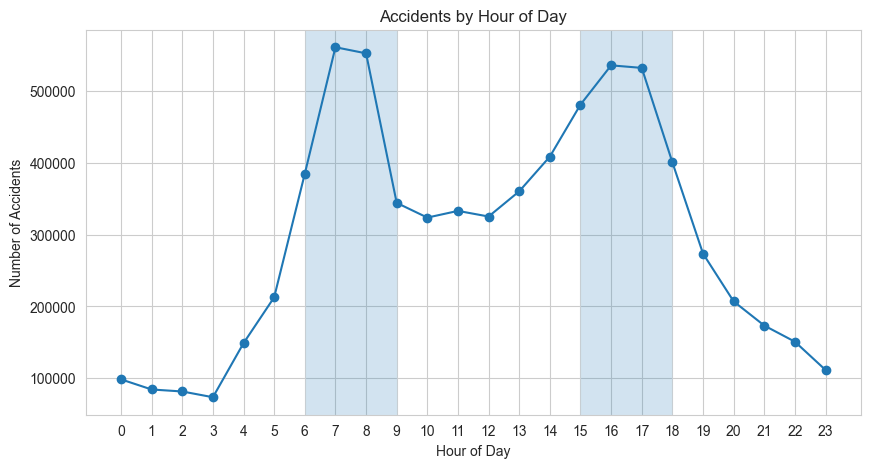

In [38]:
import matplotlib.pyplot as plt

hourly_pd = df.groupBy("hour").agg(
    count("*").alias("accident_count")
).orderBy("hour").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["hour"], hourly_pd["accident_count"], marker="o")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.axvspan(6, 9, alpha=0.2) 
plt.axvspan(15, 18, alpha=0.2)
plt.show()

### What this graph tells us?
- There are clear peak hours during both the morning and afternoon for the amount of accidents happening 
- The peaks do seem to be aligned with rush-hours

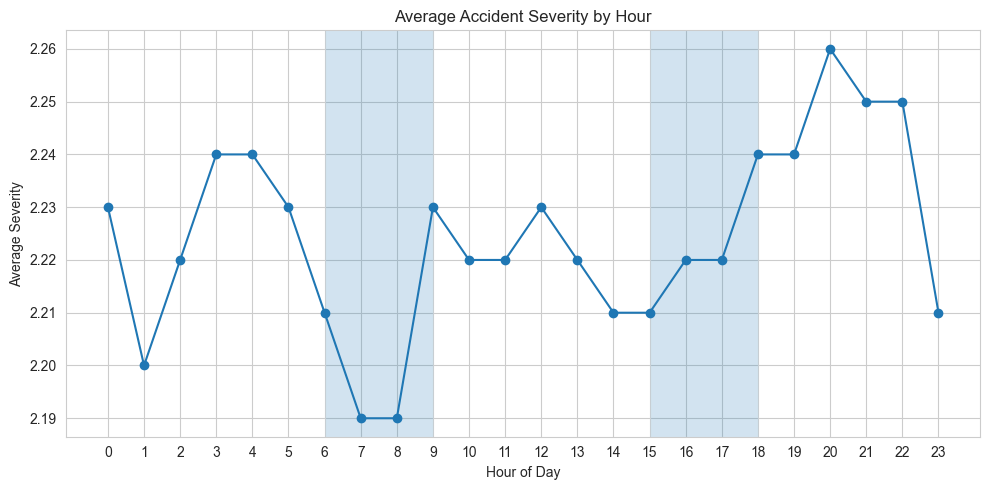

In [39]:
hourly_pd = df.groupBy("hour").agg(
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("hour").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["hour"], hourly_pd["avg_severity"], marker="o")
plt.title("Average Accident Severity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Severity")
plt.xticks(range(24))
plt.tight_layout()
plt.axvspan(6, 9, alpha=0.2) 
plt.axvspan(15, 18, alpha=0.2)
plt.show()

### What this graph tells us?
- Severity doesn't seem to correlate much with the rush-hours
- Interestingly the two highest peaks in severity are outside of rush-hours
- The most significant peaks are timed around 4:00 and 20:00 o'clock whereas less significant peaks are around midnight and around the last hour of morning rush

# Tiina's Analysis

Top 10 cities with the highest number of accidents (top 10), the total number of accidents, the number of severe accidents (severity 3 and 4), and the percentage of severe accidents.
Visualization and map view.

In [42]:
# Top-10 kaupungit koko aineistosta
top10_cities = (
    df.groupBy("City")
      .agg(count("*").alias("accident_count"))
      .orderBy(col("accident_count").desc())
      .limit(10)
)

# Vakavat onnettomuudet (severity 3 ja 4)
df_severe = df.filter(col("Severity").isin(3, 4))

severe_counts = (
    df_severe.groupBy("City")
             .agg(count("*").alias("severe_count"))
)

# Yhdistäminen
city_stats = (
    top10_cities.join(severe_counts, on="City", how="left")
                .fillna(0)
                .withColumn(
                    "severe_percentage",
                    round((col("severe_count") / col("accident_count")) * 100, 2)
                )
                .orderBy(col("accident_count").desc())
)

# taulukko
city_stats_pd = city_stats.toPandas()
display(city_stats_pd)

,City,accident_count,severe_count,severe_percentage
0,Houston,163091,30335,18.60
1,Miami,152253,16540,10.86
2,Los Angeles,147333,35679,24.22
3,Charlotte,130452,7715,5.91
4,Dallas,125816,33957,26.99
5,Austin,94145,8971,9.53
6,Orlando,91584,6970,7.61
7,Raleigh,81943,8360,10.20
8,Nashville,69436,10964,15.79
9,Baton Rouge,68572,6709,9.78


Create a map view that displays the 10 cities with the highest number of accidents, using an aggregated representation so that only 10 points appear on the map. When clicking on a point, the map should show the city name and the total number of accidents.

HTML version of the map view was also generated. The HTML file can be opened in any web browser and contains an interactive map that allows users to explore city locations and accident counts without requiring a Python environment.

In [43]:
from pyspark.sql.functions import col, avg, first

# haetaan 10 kaupungia, joissa eniten onnettomuuksia
top10_df = (
    df.groupBy("City")
      .count()
      .orderBy(col("count").desc())
      .limit(10)
)

# Liitetään koordinaatit ja lasketaan koordinaattien keskiarvot
top10_agg = (
    df.join(top10_df, on="City", how="inner")
      .groupBy("City")
      .agg(
          avg("Start_Lat").alias("lat"),
          avg("Start_Lng").alias("lng"),
          first("count").alias("count")
      )
      .withColumnRenamed("City", "City")
      .orderBy(col("count").desc())
      .toPandas()
)


In [49]:
import folium
from folium.plugins import MarkerCluster


# Keskitetään kartta USA:n keskelle
m = folium.Map(location=[39.5, -98.35], zoom_start=4)


# karttapisteet
city_color = {row["City"]: "blue" for _, row in top10_agg.iterrows()}

for i, row in top10_agg.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color=city_color[row["City"]],
        fill=True,
        fill_opacity=0.8,
        popup=f"City: {row['City']}<br>Accidents: {row['count']}"
    ).add_to(m)

# Kartan tallennus
m.save("top10_cities_map.html")
m

In [ ]:
# kartan avaus selaimessa

import webbrowser
# webbrowser.open("top10_cities_map.html") # Un-comment this line to open the map in your default web browser after running the code.

True

A second version that presents a table and map view of the top 10 cities with the highest number of severe traffic accidents (severity levels 3 and 4). The map markers display the city name and the number of accidents.


In [50]:
# Vakavuusluokkien severity 3 ja 4 suodatus

df_severe = df.filter(col("Severity").isin(3, 4))

# Lasketaan top 10 kaupunkia näistä onnettomuuksista
sev_top10_df = (
    df_severe.groupBy("City")
      .agg(count("*").alias("accident_count"))
      .orderBy(col("accident_count").desc())
      .limit(10)
)

# Lasketaan koordinaattien keskiarvot ja liitetään mukaan count
sev_top10_agg = (
    df_severe.join(sev_top10_df, on="City", how="inner")
      .groupBy("City", "accident_count")
      .agg(
          avg("Start_Lat").alias("lat"),
          avg("Start_Lng").alias("lng")
      )
      .orderBy(col("accident_count").desc())
      .toPandas()
)


In [51]:
from IPython.display import display

# Näytetään tulos myös taulukkona
sev_top10_table = sev_top10_agg[["City", "accident_count"]]
display(sev_top10_table)

# Luodaan uusi kartta joka kerta (estää duplikaatit)
m = folium.Map(location=[39.5, -98.35], zoom_start=4)

for _, row in sev_top10_agg.iterrows():

    # Kartalle piste
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.7
    ).add_to(m)

    # tekstilabel
    folium.Marker(
        location=[row["lat"], row["lng"]],
        icon=folium.DivIcon(
            html=f"""
                <div style="
                    position: relative;
                    bottom: 20px;      /* nostaa tekstin palluran yläpuolelle */
                    left: 12px;        /* siirtää hieman oikealle */
                    font-size: 12px;
                    font-weight: normal;
                    color: black;
                    white-space: nowrap;  /* pakottaa yhdelle riville */
                    background-color: rgba(255,255,255,0.8);
                    padding: 2px 4px;
                    border-radius: 3px;
                ">
                    {row['City']}: {row['accident_count']}
                </div>
            """
        )
    ).add_to(m)

#näyttää kartan notebookissa
m




,City,accident_count
0,Los Angeles,35679
1,Dallas,33957
2,Atlanta,33366
3,Houston,30335
4,Chicago,18674
5,Miami,16540
6,Jacksonville,15886
7,Minneapolis,12372
8,Denver,12280
9,San Diego,12072


In [53]:
# tallentaminen HTML-tiedostoksi
m.save("severe_top10.html")
# webbrowser.open("severe_top10.html") # Un-comment this line to open the map in your default web browser after running the code.

Yearly and monthly analysis - Calculate the number of accidents on a monthly and yearly level, and visualize the top 5 cities with the highest number of accidents


In [54]:
from pyspark.sql.functions import col, year, month, count

# dataFramen luominen vuosista ja kuukausista
df_dates = (
    df.withColumn("Year", year(col("Start_Time")))
      .withColumn("Month", month(col("Start_Time")))
)
top_years = (
    df_dates.groupBy("Year")
            .agg(count("*").alias("accident_count"))
            .orderBy(col("accident_count").desc())
            .limit(5)
)

top_years_list = [row["Year"] for row in top_years.collect()]

monthly_top = (
    df_dates.filter(col("Year").isin(top_years_list))
            .groupBy("Year", "Month")
            .agg(count("*").alias("accident_count"))
            .orderBy("Year", "Month")
)

monthly_pd = monthly_top.toPandas()
top_years_pd = top_years.toPandas()   # sisältää Year + accident_count


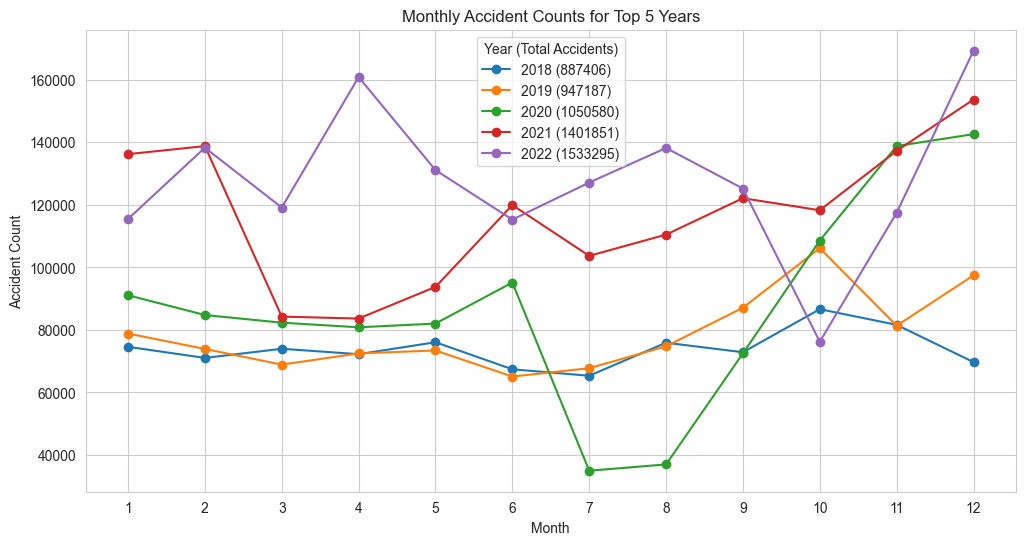

In [55]:
plt.figure(figsize=(12, 6))

for year in sorted(top_years_list):
    # Kuukausidata
    data = monthly_pd[monthly_pd["Year"] == year]

    # Haetaan vuosikohtainen kokonaismäärä legendaa varten
    total = int(top_years_pd[top_years_pd["Year"] == year]["accident_count"].iloc[0])

    # Piirretään viiva
    plt.plot(
        data["Month"],
        data["accident_count"],
        marker="o",
        label=f"{year} ({total})"
    )

plt.title("Monthly Accident Counts for Top 5 Years")
plt.xlabel("Month")
plt.ylabel("Accident Count")
plt.xticks(range(1, 13))  # tammikuu → joulukuu
plt.legend(title="Year (Total Accidents)")
plt.grid(True)
plt.show()

The highest number of accidents occurred in 2019.
Calculate the number of accidents on a monthly basis and display the top 5 cities with the most accidents.

In [57]:
# Suodatus vuoden 2019 vakavista onnettomuuksista
import pyspark.sql.functions as F
severe_2019 = (
    df_clean
    .filter(F.col("Severity").isin(3, 4))
    .filter(F.year("Start_Time") == 2019)
)

# Lasketaan näistä top5
city_totals_2019 = (
    severe_2019
    .groupBy("City")
    .count()
    .orderBy(F.col("count").desc())
)

top5_cities = city_totals_2019.limit(5).select("City")

# Kuukausikohtaisten määrien laskenta
monthly_city_counts_top5 = (
    severe_2019
    .withColumn("Month", F.month("Start_Time"))
    .join(top5_cities, on="City", how="inner")
    .groupBy("City", "Month")
    .count()
    .orderBy("City", "Month")
)

monthly_pd = monthly_city_counts_top5.toPandas()

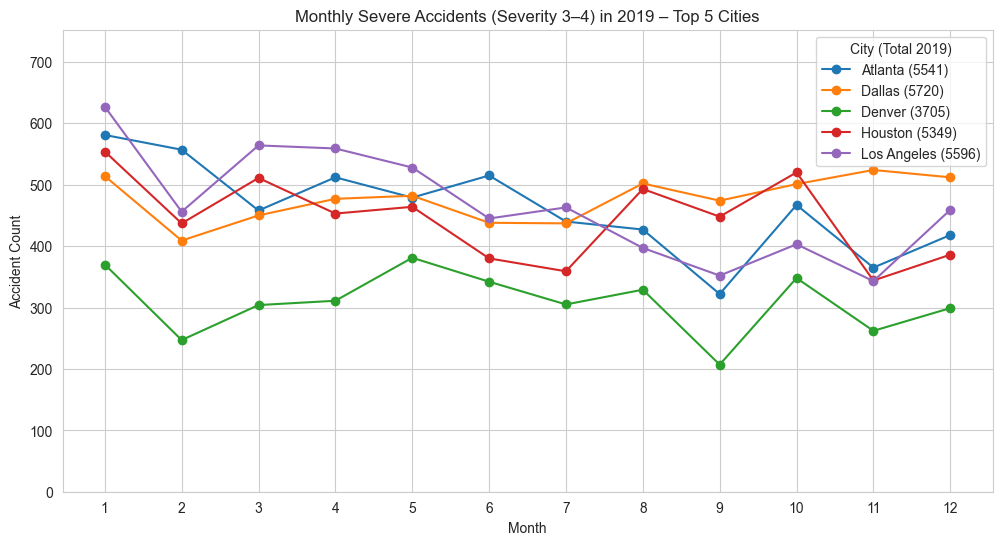

In [58]:
# visualisonti

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Haetaan vuosittaiset kokonaismäärät legendaa varten
city_totals_pd = city_totals_2019.toPandas()   # sisältää City + count

for city in monthly_pd["City"].unique():
    data = monthly_pd[monthly_pd["City"] == city]

    # Haetaan kaupungin vuosittainen kokonaismäärä
    total = int(city_totals_pd[city_totals_pd["City"] == city]["count"].iloc[0])

    # Piirretään viiva
    plt.plot(
        data["Month"],
        data["count"],
        marker="o",
        label=f"{city} ({total})"
    )

plt.title("Monthly Severe Accidents (Severity 3–4) in 2019 – Top 5 Cities")
plt.xlabel("Month")
plt.ylabel("Accident Count")

# Kuukaudet 1–12
plt.xticks(range(1, 13))

# Y-akselille lisää tilaa (20 % ylimääräistä)
ymax = monthly_pd["count"].max()
plt.ylim(0, ymax * 1.2)

# Legenda oikeaan yläkulmaan
plt.legend(title="City (Total 2019)", loc="upper right")

plt.grid(True)
plt.show()